# 02 — The three optimisation strategies

This notebook explains and illustrates, **at a single rebalance date**, the three portfolio construction methods that the walk-forward backtest (notebook 03) will run at *every* rebalance date:

1. **Markowitz max-Sharpe** — the classical tangency portfolio: $\max_w \; (w^\top\mu - r_f)\,/\,\sqrt{w^\top\Sigma w}$
2. **Michaud resampled portfolio** — $w^* = \frac{1}{M}\sum_{m=1}^{M} w_m$, with $w_m$ optimal on simulated $(\mu_m, \Sigma_m)$ (Michaud & Michaud, 2008)
3. **Black–Litterman** *(optional extension)* — $E[R] = \left[(\tau\Sigma)^{-1} + P^\top\Omega^{-1}P\right]^{-1}\left[(\tau\Sigma)^{-1}\pi + P^\top\Omega^{-1}Q\right]$ (Idzorek, 2005)

## Subjective parameters (declared and justified)

| Choice | Value | Justification |
|---|---|---|
| Estimation window | **60 months** (36m sensitivity in nb 03) | long enough for a stable 16×16 Σ (60 obs > 16 assets), short enough to adapt across regimes |
| Rebalancing | **monthly** (quarterly sensitivity in nb 03) | assignment allows monthly/quarterly; monthly reacts faster around crises |
| Constraints | long-only, no leverage, **25% per-ETF cap**, **60% per-bucket cap** | realistic mandate; prevents the corner solutions typical of unconstrained MV |
| Covariance | **Ledoit–Wolf shrinkage** (sample as comparison) | 16 assets on 60 obs → noisy sample Σ; shrinkage is the standard fix |
| Risk-free | 3m T-bill (FRED TB3MS), monthly | consistent with monthly rebalancing |
| Michaud paths | **M = 500**, fixed seed | weight averages stabilise well before 500 (checked below); seed → reproducibility |
| BL calibration | τ = 0.05, momentum views, Idzorek Ω | detailed in section 4 |

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from src import config, data, estimators, optimizers, plotting

plotting.setup_style()
monthly, returns, rf = data.load_dataset()

# Illustration date: the COVID trough — estimation inputs are maximally 'shocked'
T = pd.Timestamp("2020-03-31")
window = returns.loc[:T].tail(config.ESTIMATION_WINDOW)
rf_annual = float((1 + rf.loc[T]) ** 12 - 1)

mu = estimators.mean_historical(window)
cov_lw = estimators.cov_ledoit_wolf(window)
cov_sample = estimators.cov_sample(window)
print(f"Rebalance date: {T:%Y-%m-%d} | rf = {rf_annual:.2%} | window: {window.index[0]:%Y-%m} -> {window.index[-1]:%Y-%m}")

Rebalance date: 2020-03-31 | rf = 0.29% | window: 2015-04 -> 2020-03


## 1. Classical Markowitz max-Sharpe

Tangency portfolio on $(\hat\mu, \hat\Sigma_{LW})$ under the common constraint set. The Ledoit–Wolf shrinkage intensity below quantifies how noisy the sample covariance is at this date.

In [2]:
from sklearn.covariance import LedoitWolf
print(f"Ledoit-Wolf shrinkage intensity at {T:%Y-%m}: {LedoitWolf().fit(window.values).shrinkage_:.2f}")

w_mkw = optimizers.max_sharpe(mu, cov_lw, rf_annual)
w_mkw[w_mkw > 0].sort_values(ascending=False).to_frame("Markowitz weight").style.format("{:.1%}")

Ledoit-Wolf shrinkage intensity at 2020-03: 0.14


,Markowitz weight
Ticker,
QQQ,24.9%
IEF,20.5%
SHY,16.2%
AGG,11.9%
TLT,11.5%
BIL,10.8%
GLD,4.3%


### The Markowitz enigma: instability to small input changes

Michaud (1989) calls mean–variance optimisers *"estimation-error maximisers"*: tiny changes in $\hat\mu$ produce violently different portfolios. We show it by moving the estimation window by just ±3 months:

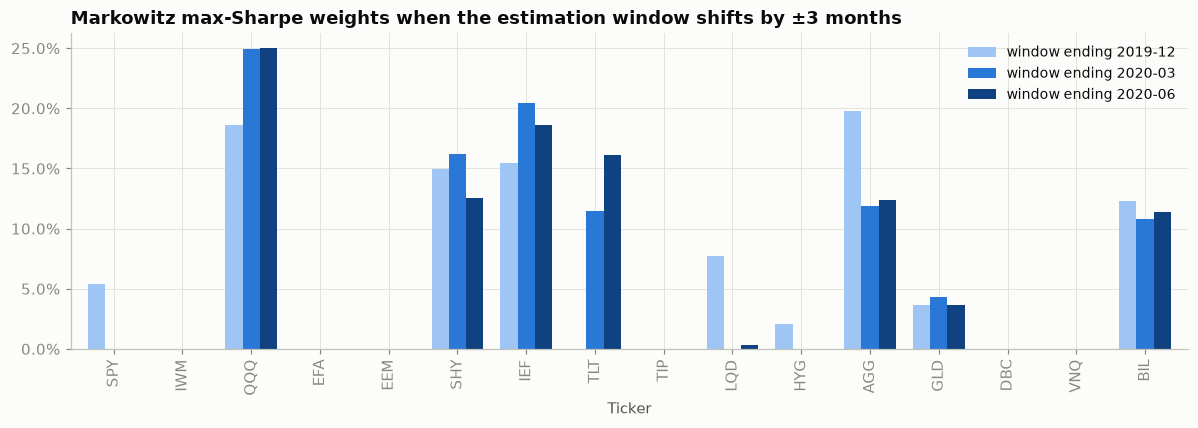

In [3]:
shifted = {}
for shift in [-3, 0, 3]:
    t_s = returns.loc[:T].index[-1 + shift] if shift < 0 else (returns.loc[:T + pd.offsets.MonthEnd(shift)].index[-1])
    win = returns.loc[:t_s].tail(config.ESTIMATION_WINDOW)
    shifted[f"window ending {t_s:%Y-%m}"] = optimizers.max_sharpe(
        estimators.mean_historical(win), estimators.cov_ledoit_wolf(win), rf_annual)
shifted = pd.DataFrame(shifted)

fig, ax = plt.subplots(figsize=(11, 4))
shifted.plot.bar(ax=ax, color=["#9ec5f4", "#2a78d6", "#104281"], width=0.75)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.set_title("Markowitz max-Sharpe weights when the estimation window shifts by ±3 months", loc="left")
ax.legend(fontsize=9)
fig.tight_layout()
plotting.savefig(fig, "02_markowitz_instability")
plt.show()

## 2. Michaud resampled portfolio

For each of $M = 500$ Monte Carlo paths we simulate 60 months of returns from $N(\hat\mu/12, \hat\Sigma/12)$, re-estimate $(\mu_m, \Sigma_m)$, solve the **same constrained max-Sharpe problem**, and average the resulting weights. The averaging washes out the part of each optimal portfolio that is only chasing sampling noise.

In [4]:
w_mich = optimizers.michaud_resampled(mu, cov_lw, rf_annual)

# Convergence check for the choice M = 500
convergence = {}
for m in [50, 100, 250, 500]:
    convergence[m] = optimizers.michaud_resampled(mu, cov_lw, rf_annual, n_resamples=m)
conv = pd.DataFrame(convergence)
print("Max |weight change| when doubling M:",
      {f"{a}->{b}": f"{(conv[b]-conv[a]).abs().max():.3f}" for a, b in [(50,100),(100,250),(250,500)]})

Max |weight change| when doubling M: {'50->100': '0.015', '100->250': '0.016', '250->500': '0.008'}


### Visualising what resampling does

Each grey dot is one resampled optimal portfolio $w_m$, evaluated on the *original* inputs $(\hat\mu, \hat\Sigma_{LW})$. The classical portfolio sits on the constrained frontier; the Michaud portfolio is the barycentre of the cloud — slightly inside the frontier (it gives up a little *estimated* efficiency in exchange for robustness to estimation error).

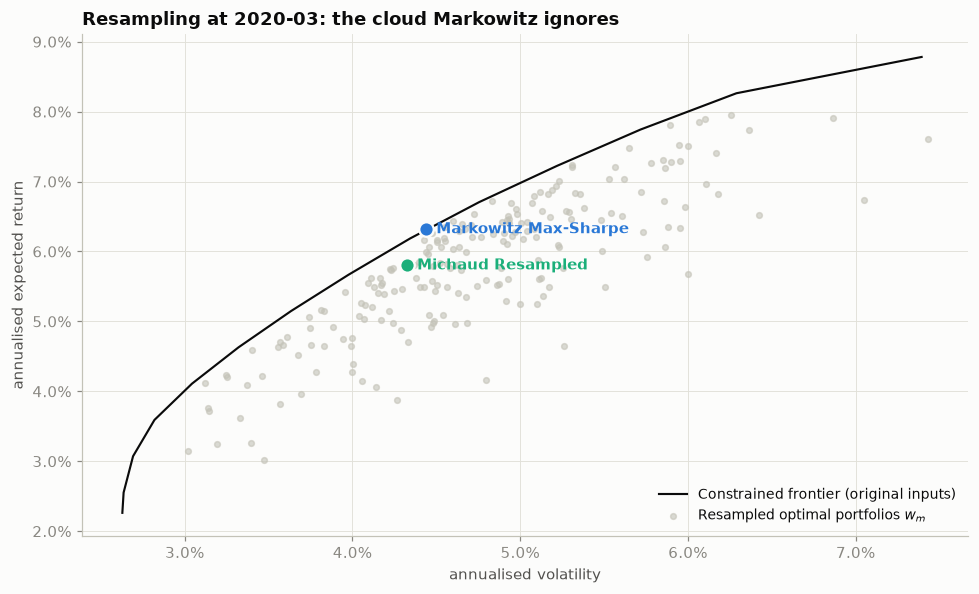

In [5]:
rng = np.random.default_rng(config.RESAMPLE_SEED)
cloud = []
for _ in range(200):
    sim = pd.DataFrame(rng.multivariate_normal(mu.values / 12, cov_lw.values / 12, size=60), columns=mu.index)
    w_m = optimizers.max_sharpe(estimators.mean_historical(sim), estimators.cov_ledoit_wolf(sim), rf_annual)
    cloud.append((np.sqrt(w_m @ cov_lw @ w_m), w_m @ mu))
cloud = np.array(cloud)

# Constrained efficient frontier on the original inputs
from pypfopt import EfficientFrontier
frontier = []
for target in np.linspace(mu.min() + 1e-4, mu.max() * 0.999, 40):
    try:
        ef = optimizers._frontier(mu, cov_lw)
        ef.efficient_return(target)
        w_f = pd.Series(ef.clean_weights())
        frontier.append((np.sqrt(w_f @ cov_lw @ w_f), w_f @ mu))
    except Exception:
        pass
frontier = np.array(sorted(frontier))

def point(w):
    return np.sqrt(w @ cov_lw @ w), w @ mu

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(frontier[:, 0], frontier[:, 1], color="#0b0b0b", lw=1.4, label="Constrained frontier (original inputs)")
ax.scatter(cloud[:, 0], cloud[:, 1], s=14, color="#c3c2b7", alpha=0.6, label="Resampled optimal portfolios $w_m$")
for w, name in [(w_mkw, "Markowitz Max-Sharpe"), (w_mich, "Michaud Resampled")]:
    x, y = point(w)
    c = plotting.STRATEGY_COLORS[name]
    ax.scatter([x], [y], s=90, color=c, zorder=5, edgecolor="#fcfcfb", linewidth=1.5)
    ax.annotate(f"  {name}", xy=(x, y), color=c, fontweight="bold", fontsize=10, va="center")
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.set_xlabel("annualised volatility"); ax.set_ylabel("annualised expected return")
ax.set_title(f"Resampling at {T:%Y-%m}: the cloud Markowitz ignores", loc="left")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plotting.savefig(fig, "02_michaud_cloud")
plt.show()

## 3. Black–Litterman (optional extension — included)

The assignment requires us to state explicitly **how views are generated** and **how Ω and τ are calibrated**:

- **Prior** $\pi$: reverse-optimised equilibrium returns, $\pi = \delta\,\Sigma\,w_{mkt} + r_f$, with proxy market weights declared in `config.MARKET_WEIGHTS` (approximate relative AUM of the 16 ETFs) and risk aversion $\delta$ implied from the market index (clipped to [1, 6] for stability).
- **Views**: one *relative* view per rebalance, generated **mechanically with no look-ahead** from the classic **12–1 momentum** signal: the equal-weighted basket of the top-3 momentum assets will outperform the bottom-3 basket. $Q$ = half of the trailing 12m spread (a conservative persistence assumption). This is our systematic, regime-reactive 'investor view' — tying BL to the research question (momentum views load on crisis winners and fade crisis losers).
- **Ω**: **Idzorek (2005)** method, with view confidence scaled by signal strength: $\text{conf} = \text{clip}(|spread|/0.40,\; 0.20,\; 0.80)$ — a stronger momentum spread ⇒ more confident view.
- **τ = 0.05**: standard literature value (He–Litterman); the sensitivity check below shows the posterior barely moves for τ ∈ [0.01, 0.10] because Idzorek's Ω scales with τ.

In [6]:
prices_hist = monthly.loc[:T]
w_bl, diag = optimizers.black_litterman_weights(prices_hist, cov_lw, rf_annual, market_prices=prices_hist[config.MARKET_INDEX])

view_assets = diag["P"][diag["P"] != 0]
print(f"View at {T:%Y-%m}: long {list(view_assets[view_assets>0].index)} vs short {list(view_assets[view_assets<0].index)}")
print(f"Q = {diag['Q']:.2%} p.a. | Idzorek confidence = {diag['confidence']:.0%} | delta = {diag['delta']:.2f}")

# tau sensitivity
for tau in [0.01, 0.05, 0.10]:
    w_tau, _ = optimizers.black_litterman_weights(prices_hist, cov_lw, rf_annual, prices_hist[config.MARKET_INDEX], tau=tau)
    print(f"tau={tau:.2f}: max |weight diff| vs tau=0.05 -> {(w_tau - w_bl).abs().max():.4f}")

View at 2020-03: long ['QQQ', 'TLT', 'GLD'] vs short ['IWM', 'EEM', 'DBC']
Q = 13.59% p.a. | Idzorek confidence = 68% | delta = 3.08
tau=0.01: max |weight diff| vs tau=0.05 -> 0.0016
tau=0.05: max |weight diff| vs tau=0.05 -> 0.0000
tau=0.10: max |weight diff| vs tau=0.05 -> 0.0018


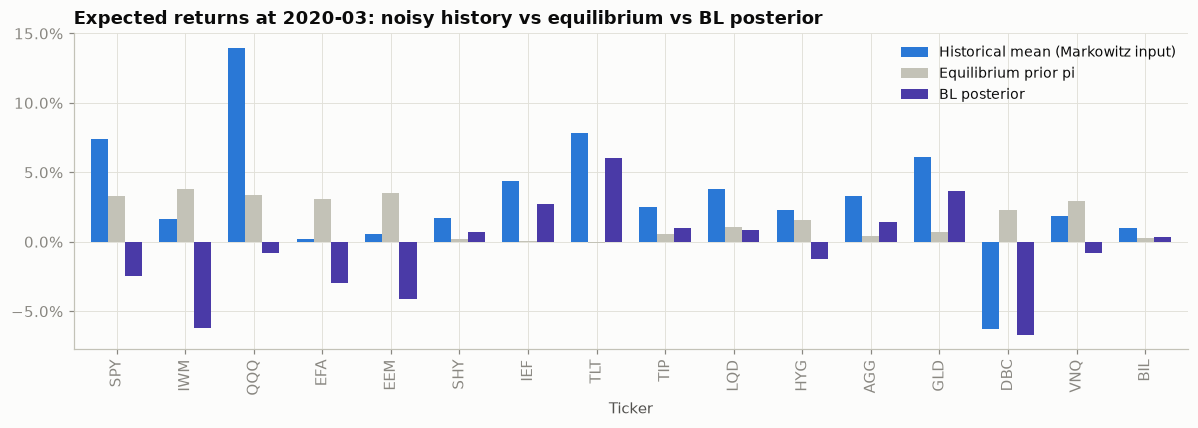

In [7]:
cmp_mu = pd.DataFrame({
    "Historical mean (Markowitz input)": mu,
    "Equilibrium prior pi": diag["pi"],
    "BL posterior": diag["mu_bl"],
})
fig, ax = plt.subplots(figsize=(11, 4))
cmp_mu.plot.bar(ax=ax, color=["#2a78d6", "#c3c2b7", "#4a3aa7"], width=0.75)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.set_title(f"Expected returns at {T:%Y-%m}: noisy history vs equilibrium vs BL posterior", loc="left")
ax.legend(fontsize=9)
fig.tight_layout()
plotting.savefig(fig, "02_bl_expected_returns")
plt.show()

The historical means (blue) after the COVID crash are extreme — exactly the noisy input that breaks Markowitz. The BL posterior (violet) stays anchored to the equilibrium prior and tilts only where the momentum view says so.

## 4. The three portfolios side by side

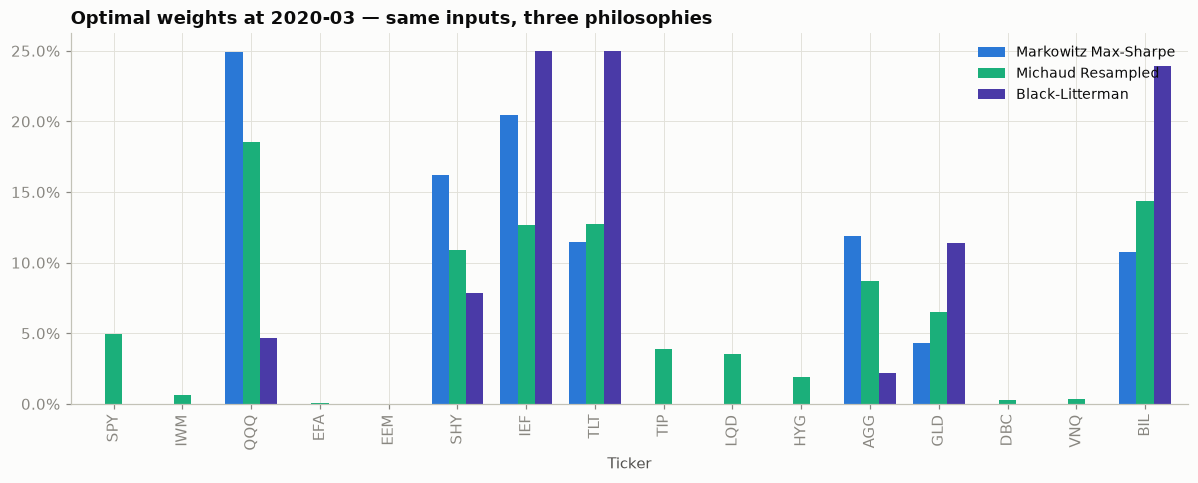

,# assets held,HHI
Markowitz Max-Sharpe,7,0.170849
Michaud Resampled,14,0.116583
Black-Litterman,7,0.204080


In [8]:
allw = pd.DataFrame({"Markowitz Max-Sharpe": w_mkw, "Michaud Resampled": w_mich, "Black-Litterman": w_bl})

fig, ax = plt.subplots(figsize=(11, 4.5))
allw.plot.bar(ax=ax, color=[plotting.STRATEGY_COLORS[c] for c in allw.columns], width=0.75)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.set_title(f"Optimal weights at {T:%Y-%m} — same inputs, three philosophies", loc="left")
ax.legend(fontsize=9)
fig.tight_layout()
plotting.savefig(fig, "02_weights_comparison")
plt.show()

diversification = (allw > 0.001).sum().rename("# assets held").to_frame()
diversification["HHI"] = (allw ** 2).sum()
diversification

## Takeaways

1. Markowitz concentrates in few assets and its weights swing violently with ±3 months of data — Michaud's *estimation-error maximiser* in action.
2. Michaud's averaging produces visibly **smoother, more diversified** weights (more assets held, lower HHI) at a negligible cost in estimated efficiency.
3. Black–Litterman disciplines the noisy historical means with an equilibrium prior plus one systematic momentum view (Idzorek Ω, τ = 0.05, both calibrations stated and stress-tested).

Whether robustness pays **out of sample** — and *when* (crises vs calm markets) — is the question for notebooks 03 and 04.